In [3]:
import pandas as pd
import jieba
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import chardet
import matplotlib
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
# 设置 Matplotlib 支持中文的字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是一种常用的中文字体
matplotlib.rcParams['font.family']='sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False  # 正确显示负号
# 设置 Matplotlib 支持中文的字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是一种常用的中文字体
matplotlib.rcParams['font.family']='sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False  # 正确显示负号

with open('brands.csv', 'rb') as file:
    print(chardet.detect(file.read()))
df = pd.read_csv('brands.csv', encoding='gbk')  # 尝试gbk编码




{'encoding': 'GB2312', 'confidence': 0.8506897166160683, 'language': 'Chinese'}


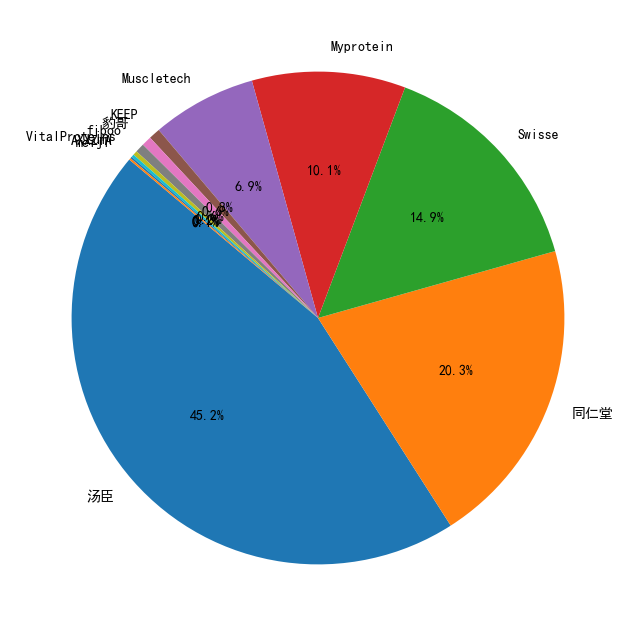

In [12]:
df.isnull().sum()
df.dropna(inplace=True)

# 读取CSV文件
df = pd.read_csv('brands.csv', encoding='gbk')

# 分词并提取品牌和功能特征
def extract_brand_features(text):
    brands = ["同仁堂", "康比特", "Swisse", "Myprotein", "Muscletech","Allmax","AXXZIA","BANNYDEER","careplus","Chodown","fiboo","gnc","KEEP","Lumi","mckin","meiji","森永海","ON奥普地帝","prosupps","VitalProteins","wildfieldhealth","安琪纽特","傲凡良","奥健","豹哥","北欧海盗","华北制药","汤臣"]  # 示例品牌列表
#     features = ["同仁堂", "康比特", "Swisse", "Myprotein", "Muscletech","Allmax","AXXZIA","BANNYDEER","careplus","Chodown","fiboo","gnc","KEEP","Lumi","mckin","meiji","森永海","ON奥普地帝","prosupps","VitalProteins","wildfieldhealth","安琪纽特","傲凡良","奥健","豹哥","北欧海盗","华北制药","汤臣"]  # 示例品牌列表
    
    features = []

    words = jieba.cut(text)
    brand = None
    for word in words:
        if word in brands:
            brand = word
        else:
            features.append(word)

    return brand, " ".join(features)

# 应用函数到商品名称列
df['品牌'], df['功能特征'] = zip(*df['商品'].apply(extract_brand_features))

# 进行品牌和购买人数的分析
brand_performance = df.groupby('品牌')['购买人数'].sum().sort_values(ascending=False)

# 可视化品牌性能
plt.figure(figsize=(10, 8))
plt.pie(brand_performance, labels=brand_performance.index, autopct='%1.1f%%', startangle=140)
# brand_performance.plot(kind='pie')
plt.title('品牌购买人数分析')
plt.xlabel('品牌')
plt.ylabel('购买人数总计')
plt.tight_layout()
plt.show()


In [9]:
df.head

<bound method NDFrame.head of           品牌                                 商品   价格   购买人数  \
0        同仁堂     同仁堂蛋白粉中老年人女性营养蛋白质粉增强免疫力官方旗舰店正品   69  20000   
1       None     康比特益生菌增肌粉瘦人增重增肌乳清蛋白质粉健肌身男官方旗舰店   79  20000   
2     Swisse  Swisse斯维诗水光粉透明质酸钠胶原蛋白肽血橙7包玻尿酸补充胶原   78  10000   
3         汤臣     汤臣倍健蛋白质粉增强免疫力中老年人免疫球蛋白营养礼盒官方旗舰  414  10000   
4         汤臣     汤臣倍健胶原蛋白肽液态饮正品官方店旗舰肽粉口服液小分子饮7袋  149  10000   
...      ...                                ...  ...    ...   
1712    None  GLGFAS乳清蛋白补充营养粉美国进口中老年人术后恢复放化疗免疫力  123     33   
1713  Swisse  Swisse斯维诗乳清蛋白粉营养蛋白质粉中老年人免疫力官方旗舰cs  155     27   
1714    None   Keep运动蛋白粉分离乳清蛋白质健身健康增肌形营养塑肌肉瘦奶茶味  152     24   
1715      汤臣   汤臣倍健蛋白粉营养蛋白质粉增强免疫力老年人女性官方店正品300g  269     11   
1716    None     中老年奶粉蛋白质粉增强提高老年人蛋白免疫力粉营养品官方旗舰店  144      9   

                                                功能特征  
0              蛋白粉 中老年人 女性 营养 蛋白质 粉 增强 免疫力 官方 旗舰店 正品  
1       康 比特 益生菌 增肌粉 瘦 人 增重 增肌 乳清 蛋白质 粉健 肌身 男 官方 旗舰店  
2            斯维诗 水光粉 透明质 酸钠 胶原蛋白 肽 血 橙 7 包玻 尿酸 补

([<matplotlib.patches.Wedge at 0x208768cd880>,
 [Text(-0.8055885939049663, -0.7490173678695436, '汤臣'),
  Text(1.0527438041060426, -0.3189521639938165, '同仁堂'),
  Text(0.739356880933614, 0.8144638743468724, 'Swisse'),
  Text(-0.06849156071969735, 1.0978656138663694, 'Myprotein'),
  Text(-0.6254569143672188, 0.9048776979626793, 'Muscletech'),
  Text(-0.825392401011543, 0.7271364276065397, 'KEEP')],
 [Text(-0.4394119603117998, -0.40855492792884196, '46.1%'),
  Text(0.5742238931487504, -0.1739739076329908, '20.7%'),
  Text(0.4032855714183348, 0.44425302237102127, '15.2%'),
  Text(-0.03735903311983491, 0.5988357893816559, '10.3%'),
  Text(-0.34115831692757387, 0.49356965343418857, '7.0%'),
  Text(-0.450214036915387, 0.3966198696035671, '0.8%')])

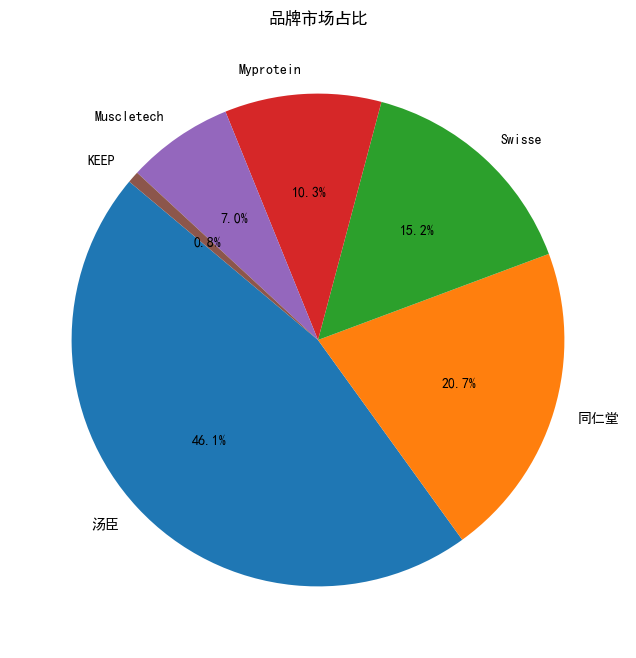

In [15]:
brand_counts = df.groupby('品牌')['购买人数'].sum().sort_values(ascending=False)

# 获取前十个品牌
top_10_brands = brand_counts.head(6)

# 设置颜色主题
colors = sns.color_palette('dark')

# 创建饼图
plt.figure(figsize=(10, 8))
plt.title('品牌市场占比')
# plt.xlabel('品牌')
# plt.ylabel('购买人数总计')
plt.pie(top_10_brands, labels=top_10_brands.index,  autopct='%1.1f%%', startangle=140)

In [17]:
# import jieba
# from collections import Counter
# import pandas as pd

# 读取数据
# df = pd.read_csv('your_file_path.csv')  # 确保文件路径正确

# 定义可能的功能性关键词
keywords = ['增强免疫力', '老年人', '女性', '健身', '乳清', '胶原蛋白', '术后恢复', '分离', '口服美白', '高蛋白', '备孕', '代餐', '鼻饲', '运动', '草饲牛', '儿童', 'bcaa', '氨基酸', '肌酸', '谷酰胺', '氮泵', '增肌']

# 分词并统计功能关键词出现的次数
feature_counts = Counter()
def extract_features(product_name):
    words = jieba.cut(product_name)
    features = [word for word in words if word in keywords]
    feature_counts.update(features)
    return " ".join(features)

# 应用函数，并创建一个新列'功能'
df['功能'] = df['商品'].apply(extract_features)

# 查看功能关键词的统计数据
print(feature_counts)

# 也可以进一步分析每个品牌或店铺的商品功能
brand_features = df.groupby('品牌')['功能'].apply(lambda x: Counter(" ".join(x).split()))

# 打印出每个品牌的功能特征统计
for brand, features in brand_features.items():
    print(f"{brand}的主要功能特征:")
    print(features)


Counter({'乳清': 912, '健身': 477, '胶原蛋白': 308, '分离': 281, '增肌': 209, '儿童': 141, '运动': 117, '女性': 116, '老年人': 58, '氨基酸': 56, '代餐': 52, '肌酸': 41, '高蛋白': 36, 'bcaa': 23, '氮泵': 18, '备孕': 4, '鼻饲': 2})
('AXXZIA', '胶原蛋白')的主要功能特征:
1.0
('AXXZIA', '乳清')的主要功能特征:
nan
('AXXZIA', '增肌')的主要功能特征:
nan
('AXXZIA', '健身')的主要功能特征:
nan
('AXXZIA', '分离')的主要功能特征:
nan
('AXXZIA', '运动')的主要功能特征:
nan
('AXXZIA', '代餐')的主要功能特征:
nan
('AXXZIA', '肌酸')的主要功能特征:
nan
('AXXZIA', '氨基酸')的主要功能特征:
nan
('AXXZIA', '女性')的主要功能特征:
nan
('AXXZIA', '老年人')的主要功能特征:
nan
('AXXZIA', '儿童')的主要功能特征:
nan
('AXXZIA', '高蛋白')的主要功能特征:
nan
('AXXZIA', 'bcaa')的主要功能特征:
nan
('KEEP', '胶原蛋白')的主要功能特征:
nan
('KEEP', '乳清')的主要功能特征:
10.0
('KEEP', '增肌')的主要功能特征:
2.0
('KEEP', '健身')的主要功能特征:
4.0
('KEEP', '分离')的主要功能特征:
1.0
('KEEP', '运动')的主要功能特征:
nan
('KEEP', '代餐')的主要功能特征:
nan
('KEEP', '肌酸')的主要功能特征:
nan
('KEEP', '氨基酸')的主要功能特征:
nan
('KEEP', '女性')的主要功能特征:
nan
('KEEP', '老年人')的主要功能特征:
nan
('KEEP', '儿童')的主要功能特征:
nan
('KEEP', '高蛋白')的主要功能特征:
nan
('KEEP', 'bcaa')的主要功能特征:
nan
('Lumi',

In [35]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import jieba

# 定义品牌列表和功能关键词列表
brands_list = ["同仁堂", "康比特", "Swisse", "Myprotein", "Muscletech", "Allmax", "AXXZIA", "BANNYDEER", "careplus", "Chodown", "fiboo", "gnc", "KEEP", "Lumi", "mckin", "meiji", "森永海", "ON奥普地帝", "prosupps", "VitalProteins", "wildfieldhealth", "安琪纽特", "傲凡良", "奥健", "豹哥", "北欧海盗", "华北制药", "汤臣"]
features_list = ["增强免疫力", "老年人", "女性", "健身", "乳清", "胶原蛋白", "术后恢复", "分离", "口服美白", "高蛋白", "备孕", "代餐", "鼻饲", "运动", "草饲牛", "儿童", "bcaa", "氨基酸", "肌酸", "谷酰胺", "氮泵", "增肌"]

# 读取CSV文件
df = pd.read_csv('brands.csv', encoding='gbk')

# 分词并提取品牌和功能特征
def extract_brand_features(text):
    words = jieba.cut(text)
    brand = None
    features = []
    for word in words:
        if word in brands_list:
            brand = word
        elif word in features_list:
            features.append(word)
    return brand, " ".join(features)

# 应用函数到商品名称列
df['品牌'], df['功能'] = zip(*df['商品'].apply(extract_brand_features))

# 进行品牌和购买人数的分析
brand_performance = df.groupby('品牌')['购买人数'].sum().sort_values(ascending=False)






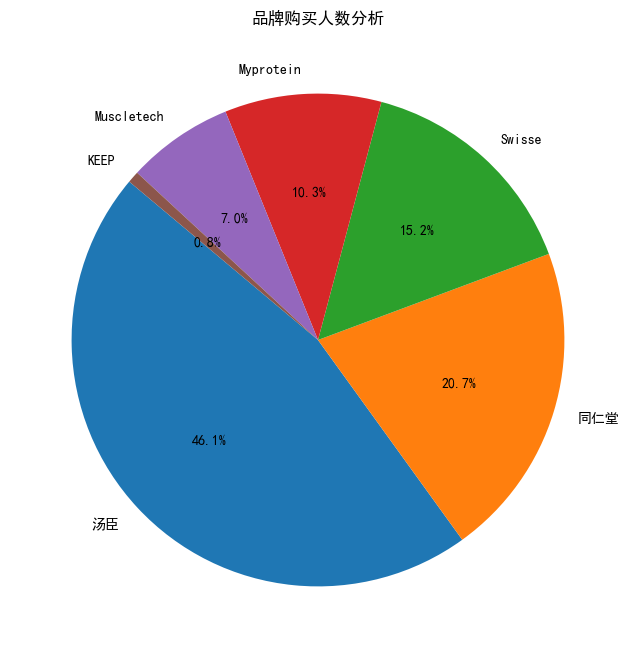

In [26]:
# 可视化品牌性能
plt.figure(figsize=(10, 8))
plt.pie(brand_performance.head(6), labels=brand_performance.head(6).index, autopct='%1.1f%%', startangle=140)
plt.title('品牌购买人数分析')
plt.show()



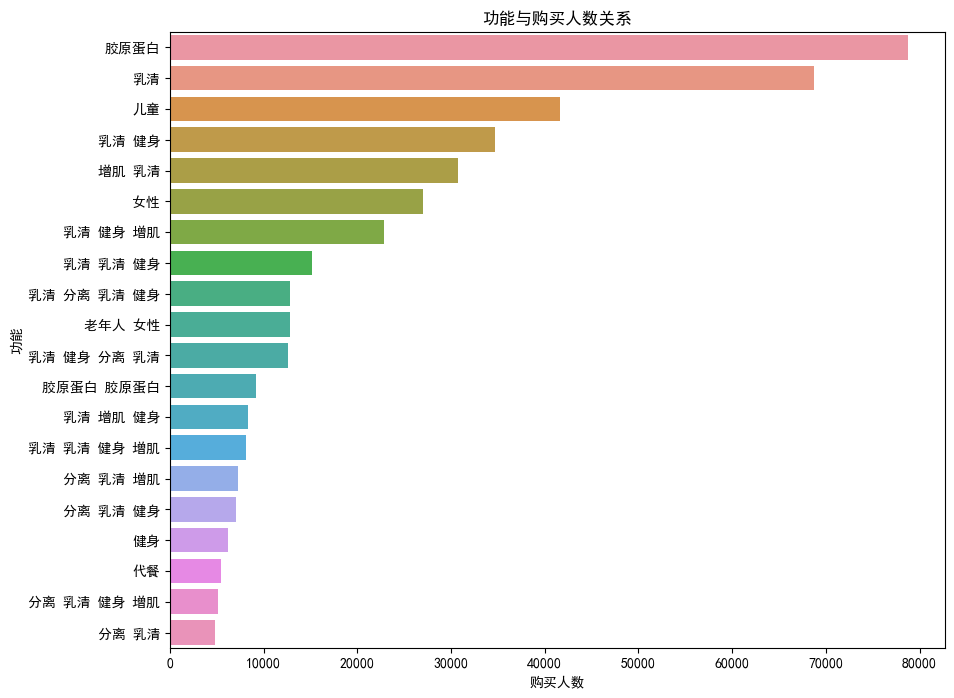

功能
胶原蛋白    78768
乳清      68780
Name: 购买人数, dtype: int64


In [39]:
# 删除购买人数最多的那一行数据
# feature_performance = feature_performance.iloc[1:]
# 移除'功能'字段为空的行
df_clean = df[df['功能'].notnull() & (df['功能'] != '')]

# 现在再进行分组和求和
feature_performance = df_clean.groupby('功能')['购买人数'].sum().sort_values(ascending=False)

# 构建购买人数与功能关键词之间的关系
# feature_performance = df.groupby('功能')['购买人数'].sum().sort_values(ascending=False)
# 可视化功能性能
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_performance.head(20).values, y=feature_performance.head(20).index)
plt.title('功能与购买人数关系')
plt.xlabel('购买人数')
plt.ylabel('功能')
plt.show()

print(feature_performance.head(2))

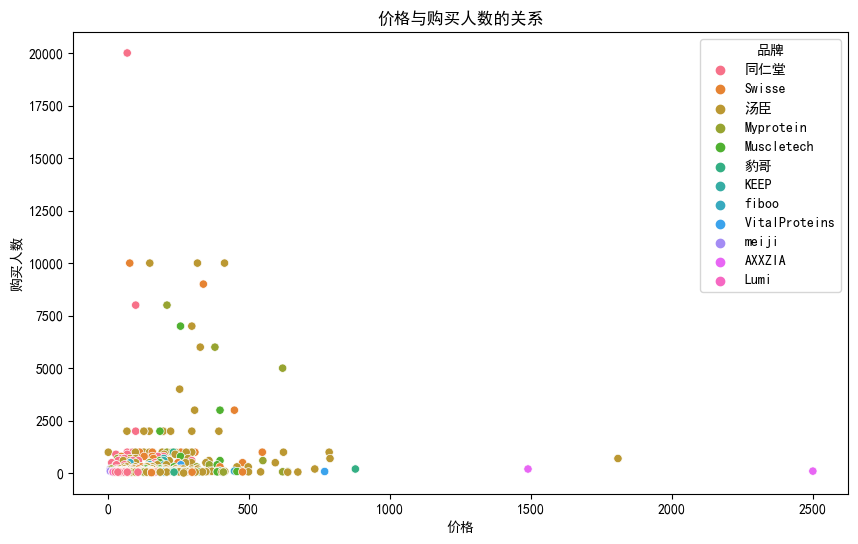

In [22]:
# 构建价格与购买人数的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='价格', y='购买人数', hue='品牌')
plt.title('价格与购买人数的关系')
plt.xlabel('价格')
plt.ylabel('购买人数')
plt.legend(title='品牌', loc='upper right')
plt.show()

# 保存处理后的数据，以便进一步分析
df.to_csv('processed_brands.csv', index=False)

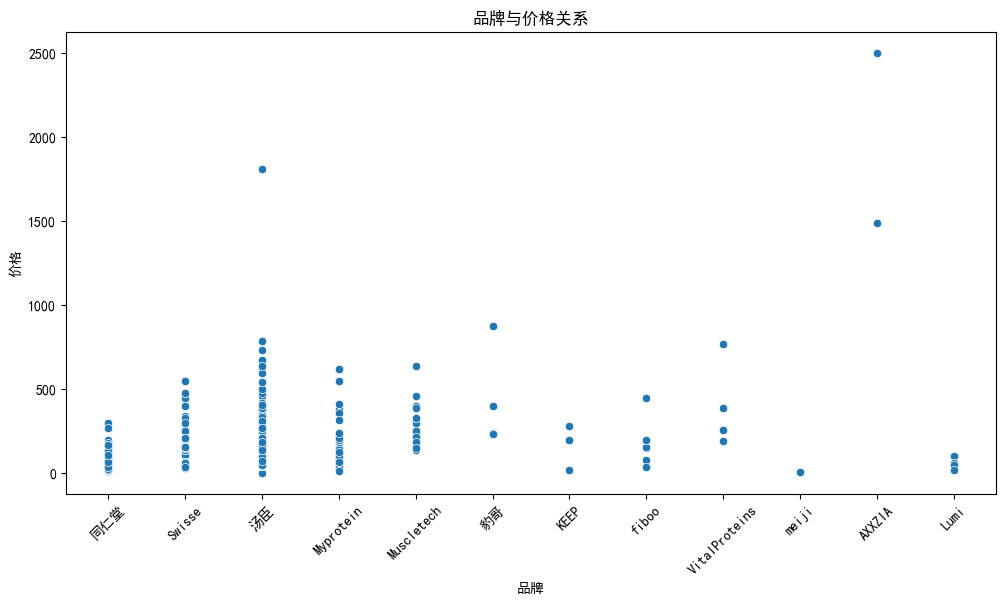

In [31]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='品牌', y='价格')
plt.xticks(rotation=45)  # 旋转品牌名称标签以便更容易阅读
plt.title('品牌与价格关系')
plt.show()


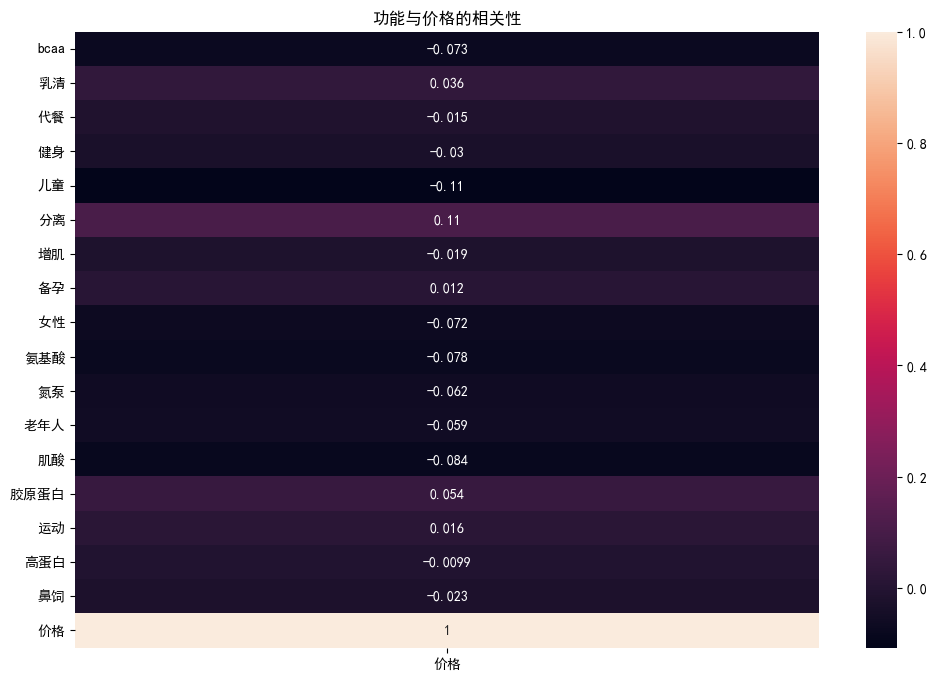

In [32]:
# 使用pd.get_dummies将功能列转换为哑变量
features_dummies = df['功能'].str.get_dummies(sep=' ')
# 将价格列添加到哑变量DataFrame中
features_dummies['价格'] = df['价格']
# 使用热图来显示功能关键词与价格之间的关系
plt.figure(figsize=(12, 8))
sns.heatmap(features_dummies.corr()[['价格']], annot=True)
plt.title('功能与价格的相关性')
plt.show()


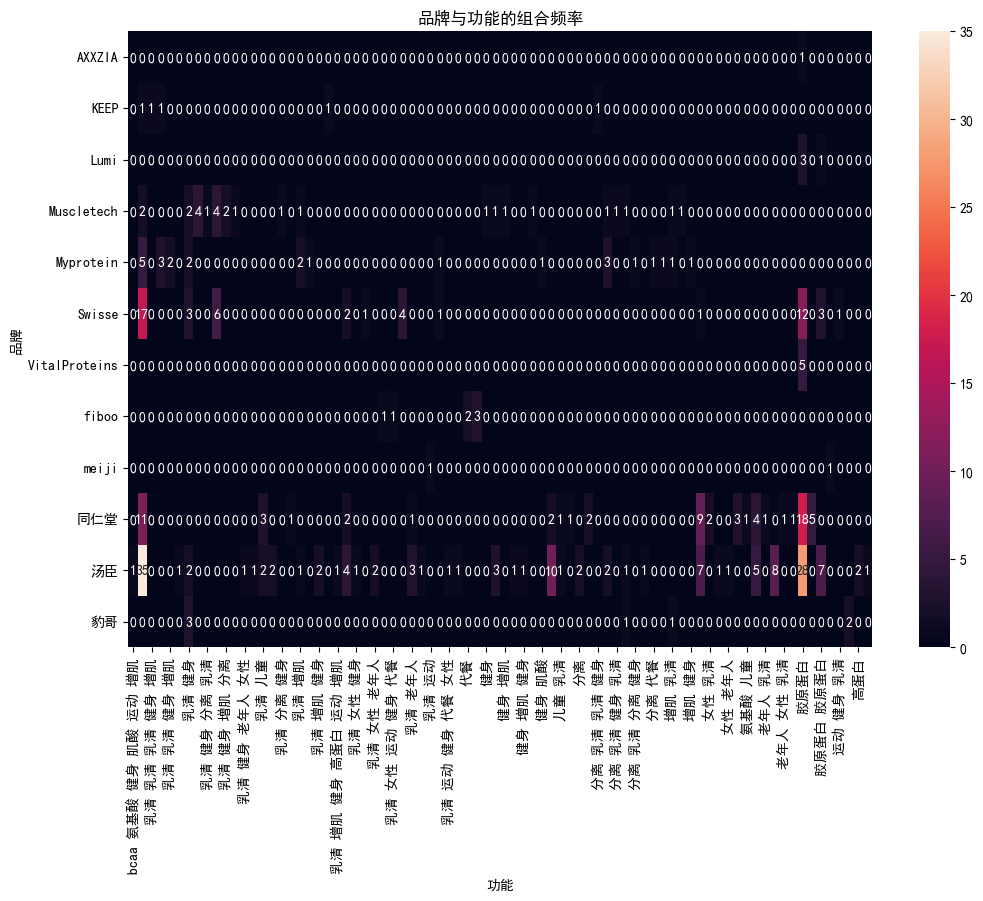

In [40]:
# 创建一个新的DataFrame来统计每个品牌的每个功能关键词的出现次数
df_clean = df[df['功能'].notnull() & (df['功能'] != '')]
brand_features = pd.crosstab(df_clean['品牌'], df_clean['功能'])
plt.figure(figsize=(12, 8))
sns.heatmap(brand_features, annot=True, fmt='d')
plt.title('品牌与功能的组合频率')
plt.show()
